# <font color='blue'> Comparing Regression Models </font>

# <font color='orange'> Random Forest </font>

In [5]:
# import libraries and the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("../data/insurance.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
# If the dataset contains object type columns, they are converted into numeric form using Label Encoding 
#so that the machine learning model can process them.

label_encoder = LabelEncoder()

df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])
df['region'] = label_encoder.fit_transform(df['region'])

print(df.head())

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [16]:
# test train split

X = df.iloc[:, 0:6].values
y = df.iloc[:,-1].values

print(X)
print(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

[[19.    0.   27.9   0.    1.    3.  ]
 [18.    1.   33.77  1.    0.    2.  ]
 [28.    1.   33.    3.    0.    2.  ]
 ...
 [18.    0.   36.85  0.    0.    2.  ]
 [21.    0.   25.8   0.    0.    3.  ]
 [61.    0.   29.07  0.    1.    1.  ]]
[16884.924   1725.5523  4449.462  ...  1629.8335  2007.945  29141.3603]


In [17]:
# training the model

regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)

regressor.fit(X_train, y_train)

RandomForestRegressor(oob_score=True, random_state=42)

Random Forest Regression Performance
Out-of-Bag Score : 0.8287
Mean Absolute Error (MAE) : 2534.45
Mean Squared Error (MSE)  : 21072114.35
Root Mean Squared Error   : 4590.44
R² Score                  : 0.8643


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


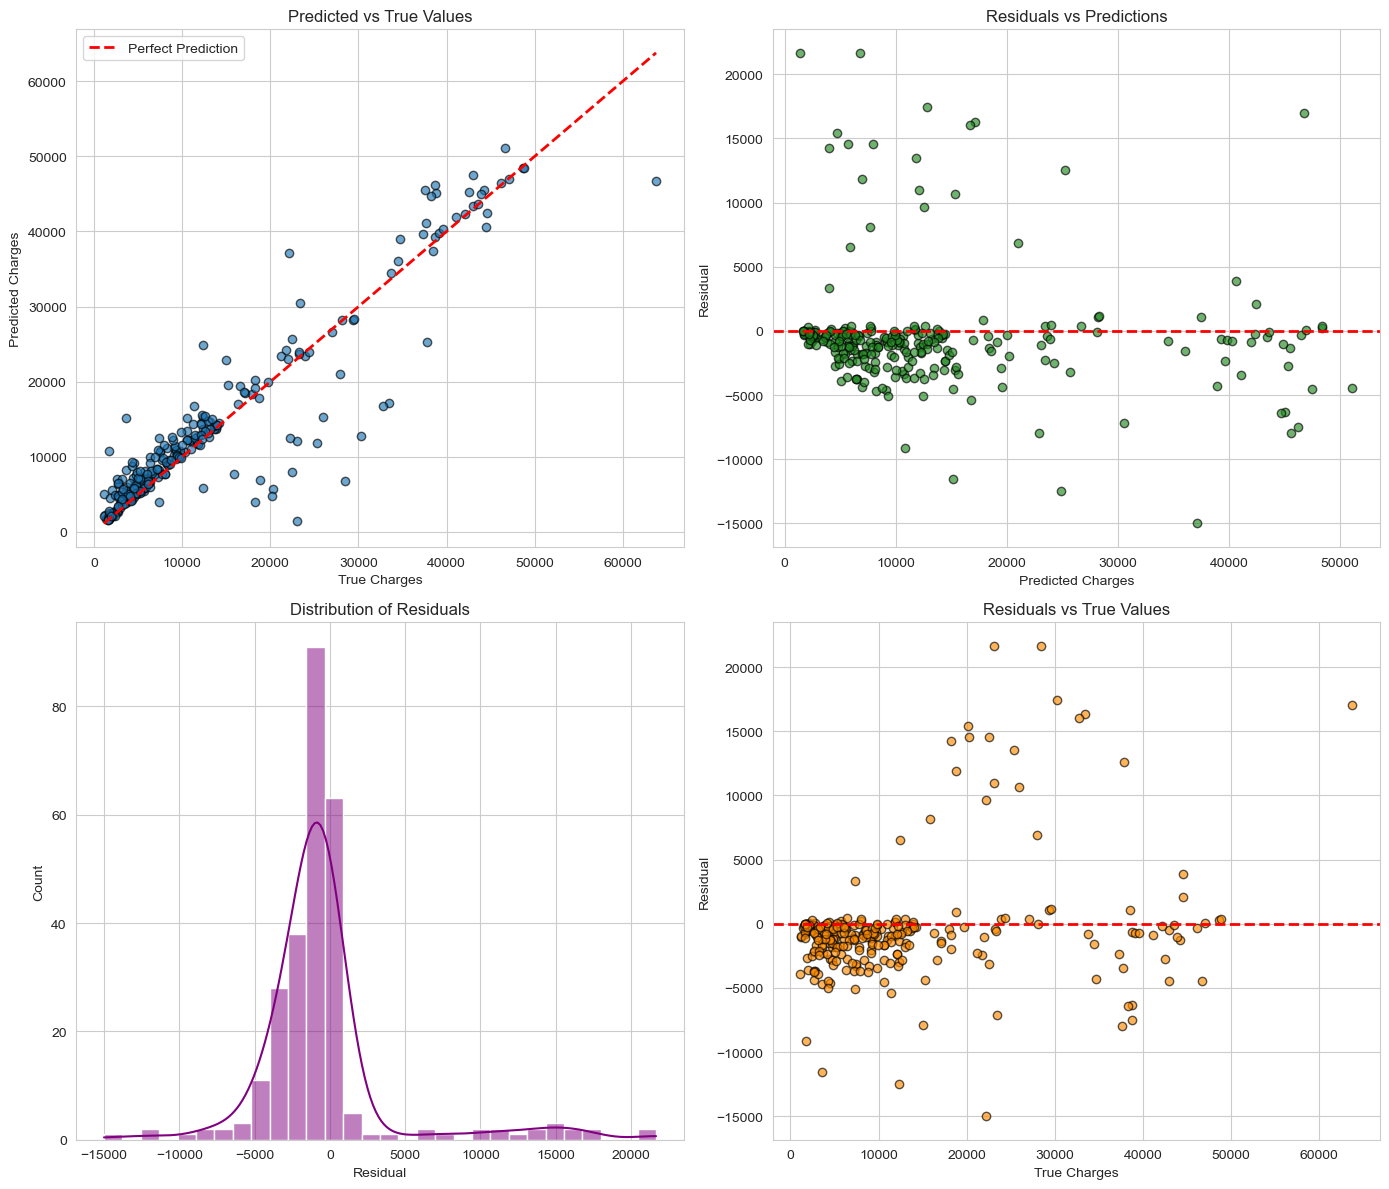

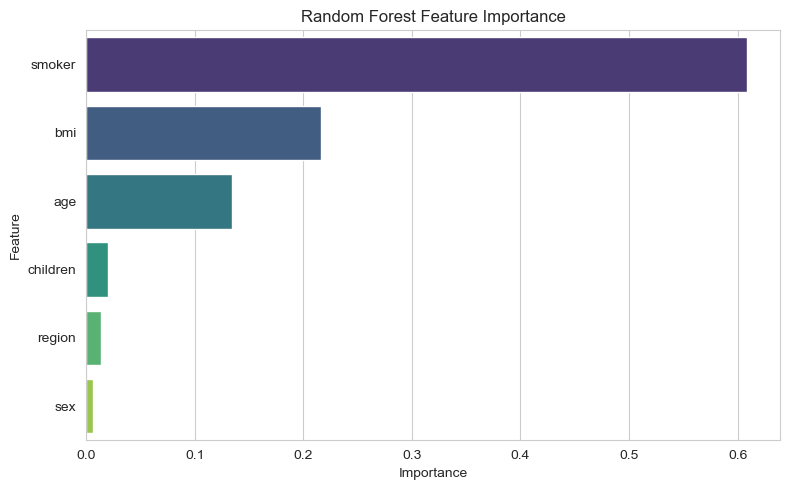

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ==========================================================
# Model Evaluation
# ==========================================================

print("=" * 50)
print("Random Forest Regression Performance")
print("=" * 50)

# Out-of-Bag Score
print(f"Out-of-Bag Score : {regressor.oob_score_:.4f}")

# Predictions
# (Assumes the model was trained using X_train as a DataFrame)
y_pred = regressor.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Mean Squared Error (MSE)  : {mse:.2f}")
print(f"Root Mean Squared Error   : {rmse:.2f}")
print(f"R² Score                  : {r2:.4f}")

# Residuals
residuals = y_test - y_pred

# ==========================================================
# Plot Style
# ==========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ==========================================================
# 1. Predicted vs True
# ==========================================================

axes[0,0].scatter(
    y_test,
    y_pred,
    alpha=0.65,
    edgecolor='k'
)

limits = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0,0].plot(
    limits,
    limits,
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

axes[0,0].set_xlabel("True Charges")
axes[0,0].set_ylabel("Predicted Charges")
axes[0,0].set_title("Predicted vs True Values")
axes[0,0].legend()

# ==========================================================
# 2. Residuals vs Predictions
# ==========================================================

axes[0,1].scatter(
    y_pred,
    residuals,
    alpha=0.65,
    edgecolor='k',
    color='forestgreen'
)

axes[0,1].axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2
)

axes[0,1].set_xlabel("Predicted Charges")
axes[0,1].set_ylabel("Residual")
axes[0,1].set_title("Residuals vs Predictions")

# ==========================================================
# 3. Residual Distribution
# ==========================================================

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color='purple',
    ax=axes[1,0]
)

axes[1,0].set_xlabel("Residual")
axes[1,0].set_ylabel("Count")
axes[1,0].set_title("Distribution of Residuals")

# ==========================================================
# 4. Residuals vs True Values
# ==========================================================

axes[1,1].scatter(
    y_test,
    residuals,
    alpha=0.65,
    edgecolor='k',
    color='darkorange'
)

axes[1,1].axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2
)

axes[1,1].set_xlabel("True Charges")
axes[1,1].set_ylabel("Residual")
axes[1,1].set_title("Residuals vs True Values")

plt.tight_layout()

plt.savefig(
    "../figures/random_forest_regression_diagnostics.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

feature_importance = (
    pd.Series(
        regressor.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index,
    hue=feature_importance.index,
    palette="viridis",
    legend=False
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "../figures/random_forest_feature_importance.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### R-squared: 0.8642686858335261

# <font color='orange'> Boosted Decision Trees </font>

Standard Gradient Boosting
MAE  : 2447.17
MSE  : 18941336.01
RMSE : 4352.16
R²   : 0.8780


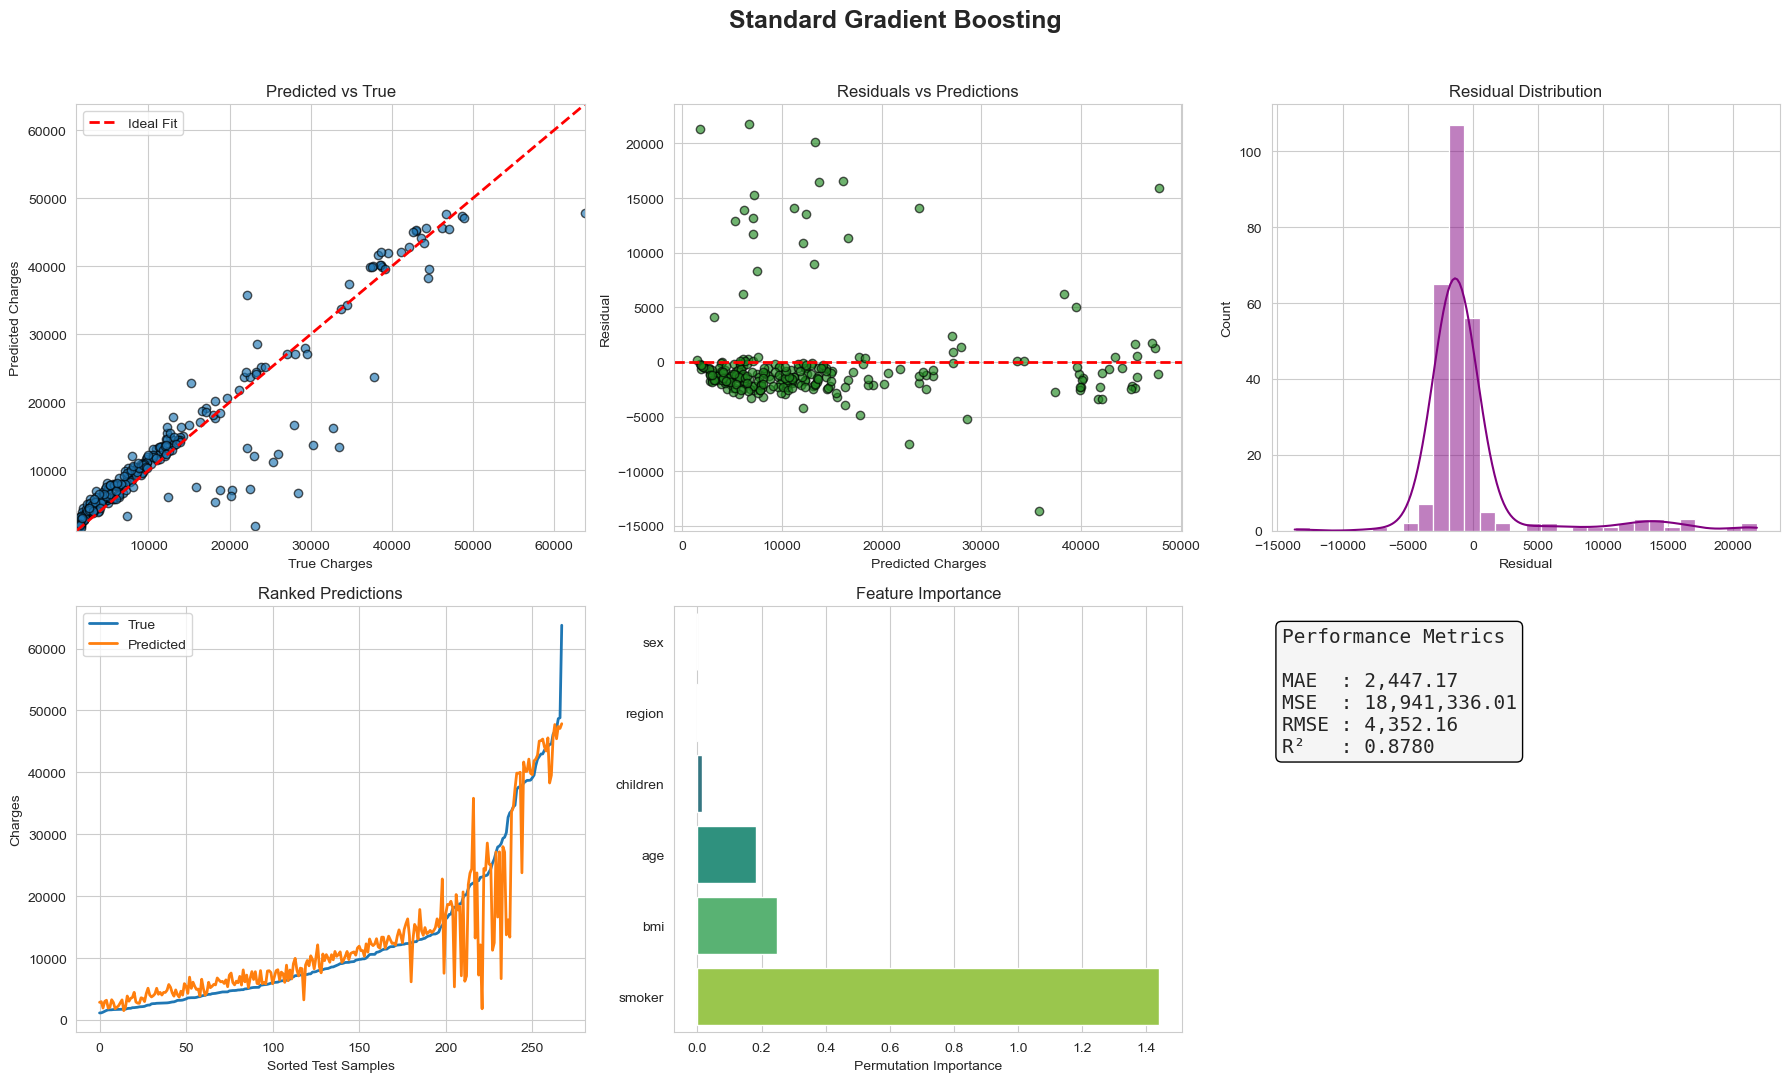

Hist Gradient Boosting
MAE  : 2609.08
MSE  : 21157781.60
RMSE : 4599.76
R²   : 0.8637


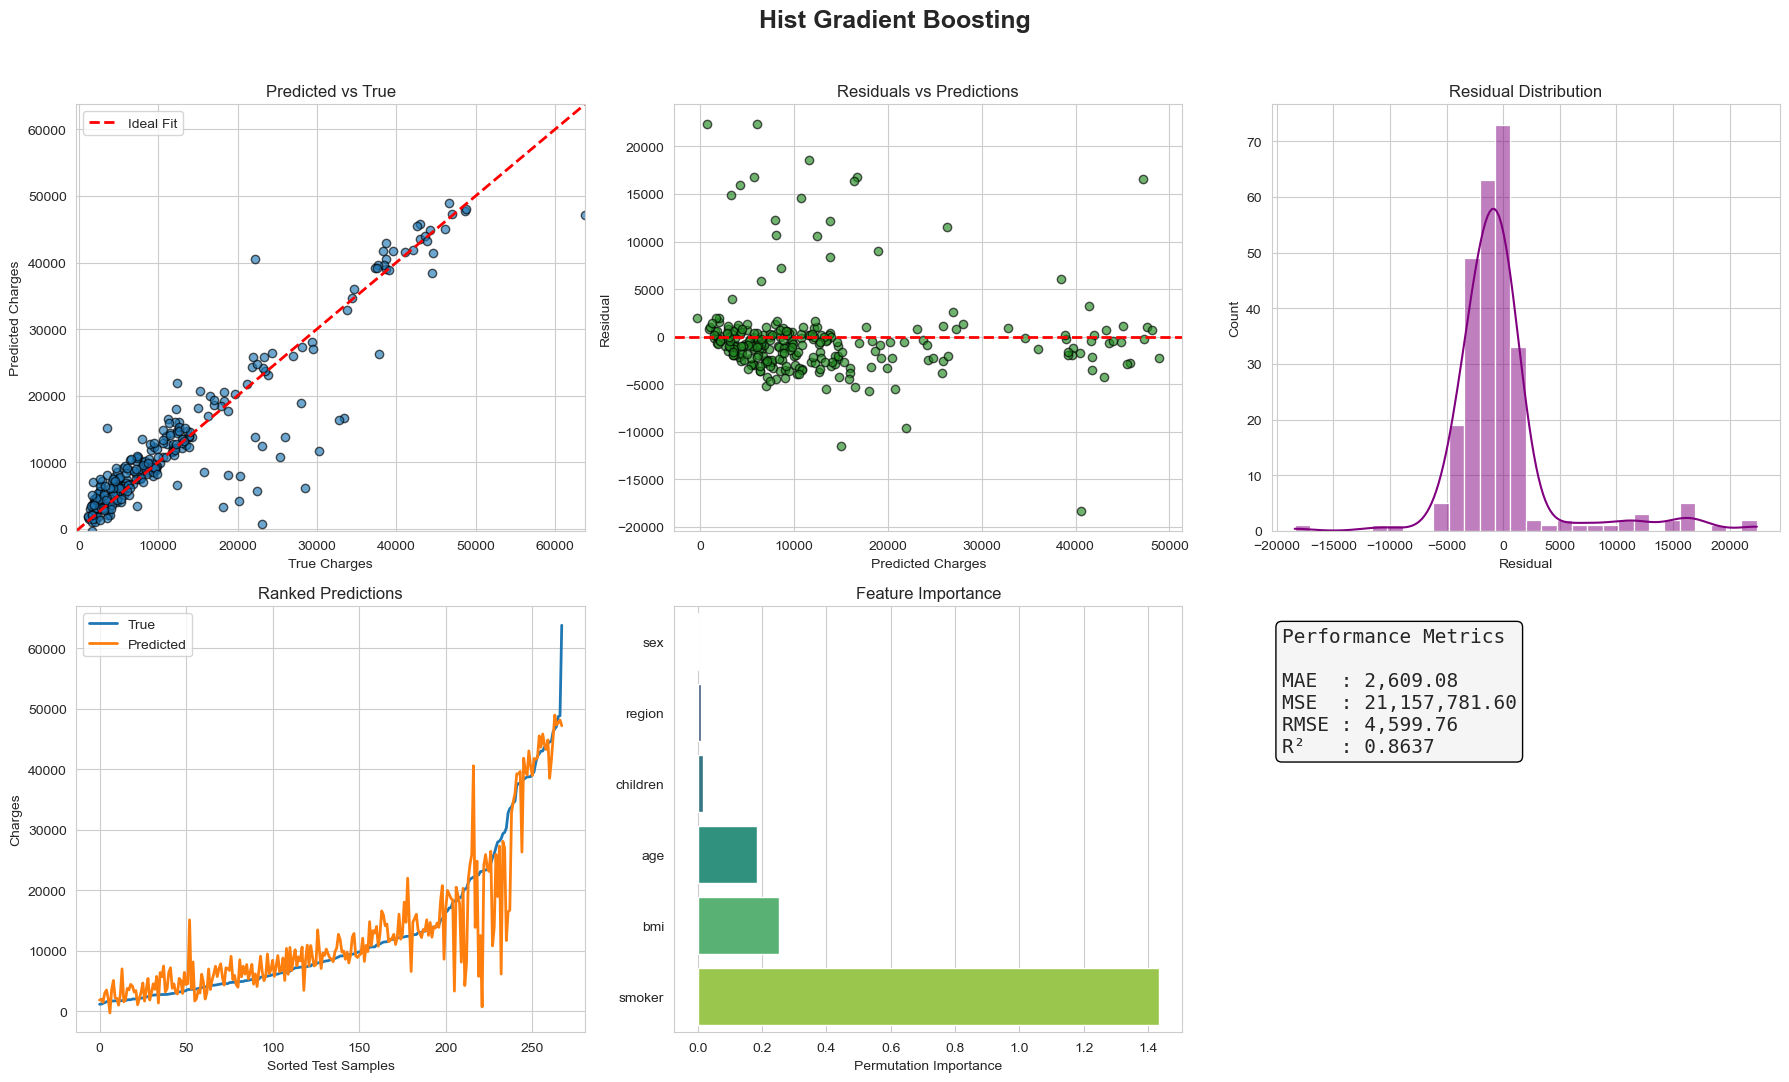

Tuned Gradient Boosting
MAE  : 2447.17
MSE  : 18941336.01
RMSE : 4352.16
R²   : 0.8780


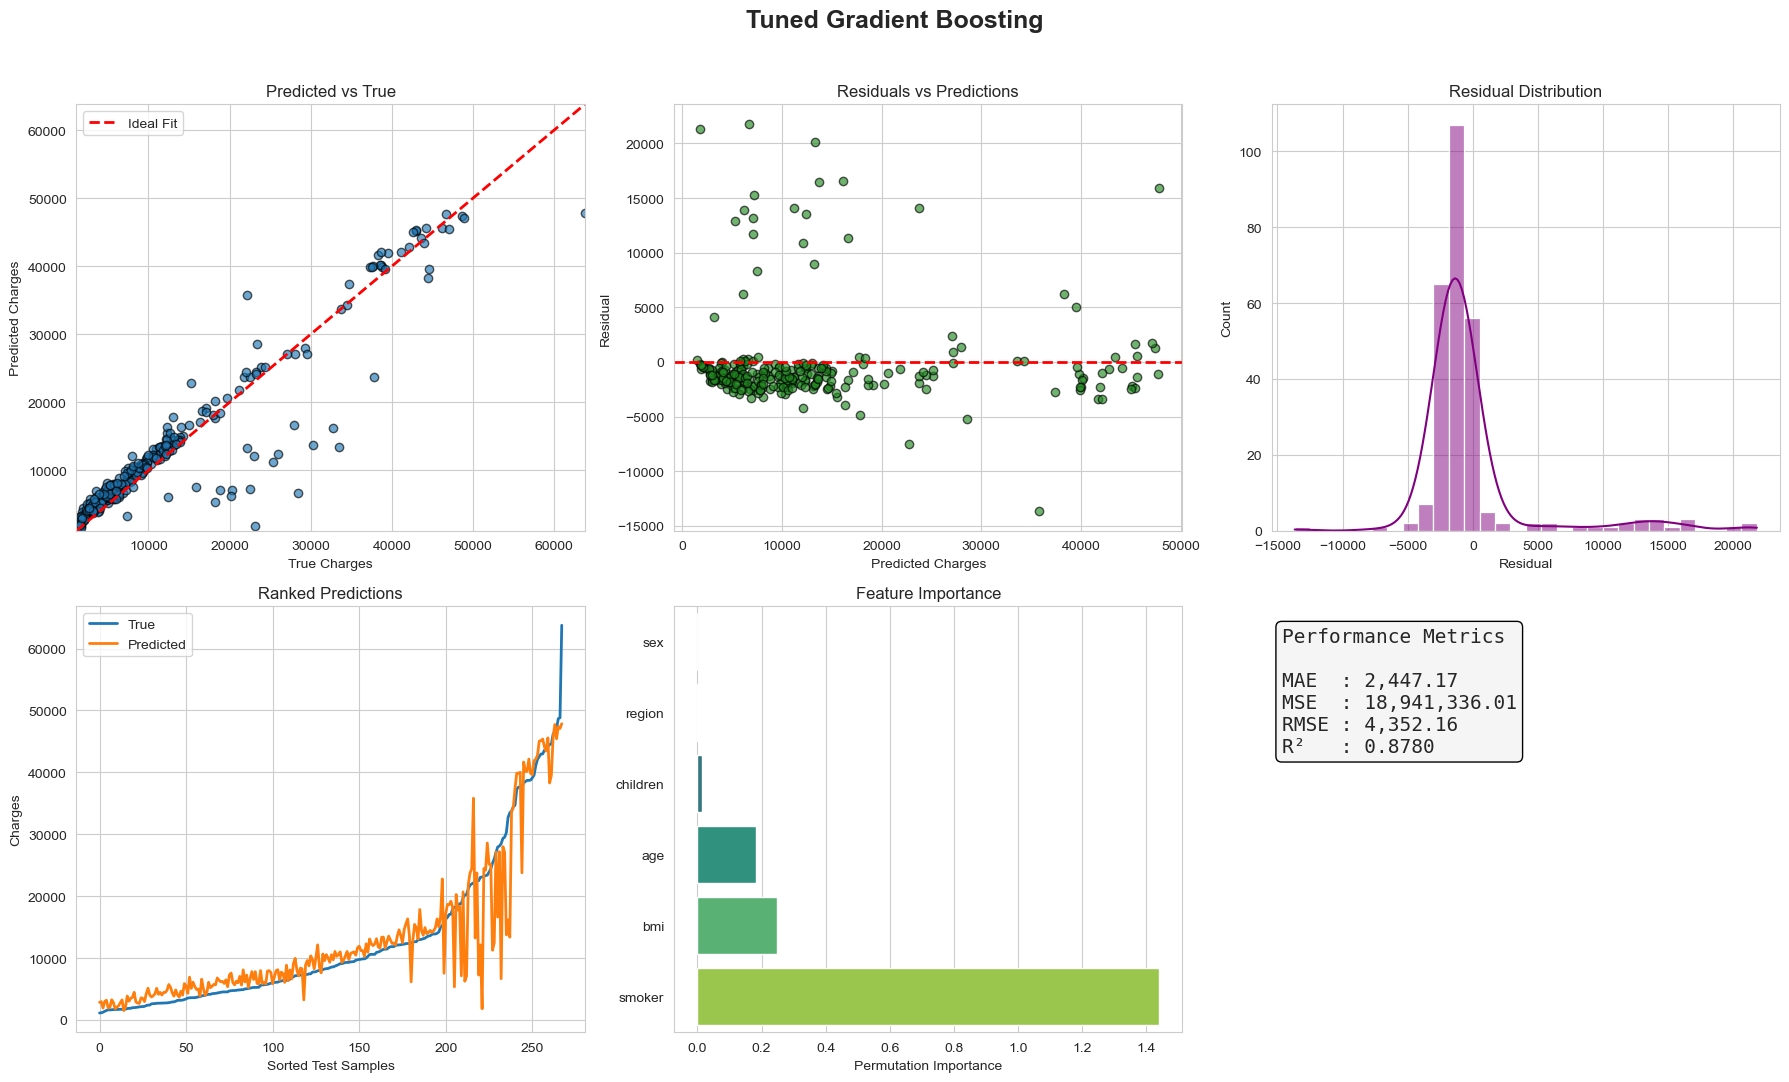

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

sns.set_style("whitegrid")

# ==========================================================
# Models
# ==========================================================

models = {
    "Standard Gradient Boosting": pipe_std,
    "Hist Gradient Boosting": pipe_hist,
    "Tuned Gradient Boosting": grid.best_estimator_
}

# ==========================================================
# Loop over models
# ==========================================================

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    # ------------------------------------------------------
    # Predictions
    # ------------------------------------------------------

    y_pred = model.predict(X_test)

    residuals = y_test - y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    # ------------------------------------------------------
    # Permutation Importance
    # ------------------------------------------------------

    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        scoring="r2"
    )

    importance = pd.Series(
        perm.importances_mean,
        index=X_test.columns
    ).sort_values()

    # ------------------------------------------------------
    # Figure
    # ------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18,11)
    )

    # ======================================================
    # 1. Predicted vs True
    # ======================================================

    ax = axes[0,0]

    ax.scatter(
        y_test,
        y_pred,
        alpha=0.65,
        edgecolor='k'
    )

    limits = [
        min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())
    ]

    ax.plot(
        limits,
        limits,
        'r--',
        linewidth=2,
        label="Ideal Fit"
    )

    ax.set_xlim(limits)
    ax.set_ylim(limits)

    ax.set_xlabel("True Charges")
    ax.set_ylabel("Predicted Charges")
    ax.set_title("Predicted vs True")
    ax.legend()

    # ======================================================
    # 2. Residual Plot
    # ======================================================

    ax = axes[0,1]

    ax.scatter(
        y_pred,
        residuals,
        alpha=0.65,
        edgecolor='k',
        color='forestgreen'
    )

    ax.axhline(
        0,
        color='red',
        linestyle='--',
        linewidth=2
    )

    ax.set_xlabel("Predicted Charges")
    ax.set_ylabel("Residual")
    ax.set_title("Residuals vs Predictions")

    # ======================================================
    # 3. Residual Histogram
    # ======================================================

    ax = axes[0,2]

    sns.histplot(
        residuals,
        bins=30,
        kde=True,
        color="purple",
        ax=ax
    )

    ax.set_xlabel("Residual")
    ax.set_title("Residual Distribution")

    # ======================================================
    # 4. Ranked Prediction Plot
    # ======================================================

    ax = axes[1,0]

    order = np.argsort(y_test.values)

    ax.plot(
        y_test.values[order],
        linewidth=2,
        label="True"
    )

    ax.plot(
        y_pred[order],
        linewidth=2,
        label="Predicted"
    )

    ax.set_xlabel("Sorted Test Samples")
    ax.set_ylabel("Charges")
    ax.set_title("Ranked Predictions")
    ax.legend()

    # ======================================================
    # 5. Feature Importance
    # ======================================================

    ax = axes[1,1]

    sns.barplot(
        x=importance.values,
        y=importance.index,
        hue=importance.index,
        dodge=False,
        legend=False,
        palette="viridis",
        ax=ax
    )

    ax.set_xlabel("Permutation Importance")
    ax.set_ylabel("")
    ax.set_title("Feature Importance")

    # ======================================================
    # 6. Performance Summary
    # ======================================================

    ax = axes[1,2]

    ax.axis("off")

    metrics = (
        f"Performance Metrics\n\n"
        f"MAE  : {mae:,.2f}\n"
        f"MSE  : {mse:,.2f}\n"
        f"RMSE : {rmse:,.2f}\n"
        f"R²   : {r2:.4f}"
    )

    ax.text(
        0.02,
        0.95,
        metrics,
        fontsize=14,
        va="top",
        family="monospace",
        bbox=dict(
            boxstyle="round",
            facecolor="whitesmoke",
            edgecolor="black"
        )
    )

    plt.suptitle(
        name,
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0,0,1,0.96])

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "")
    )

    plt.savefig(
        f"../figures/{filename}_diagnostics.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Standard Gradient Boosting is the best performer with R2 = 0.878

# <font color='orange'> ElasticNet </font>

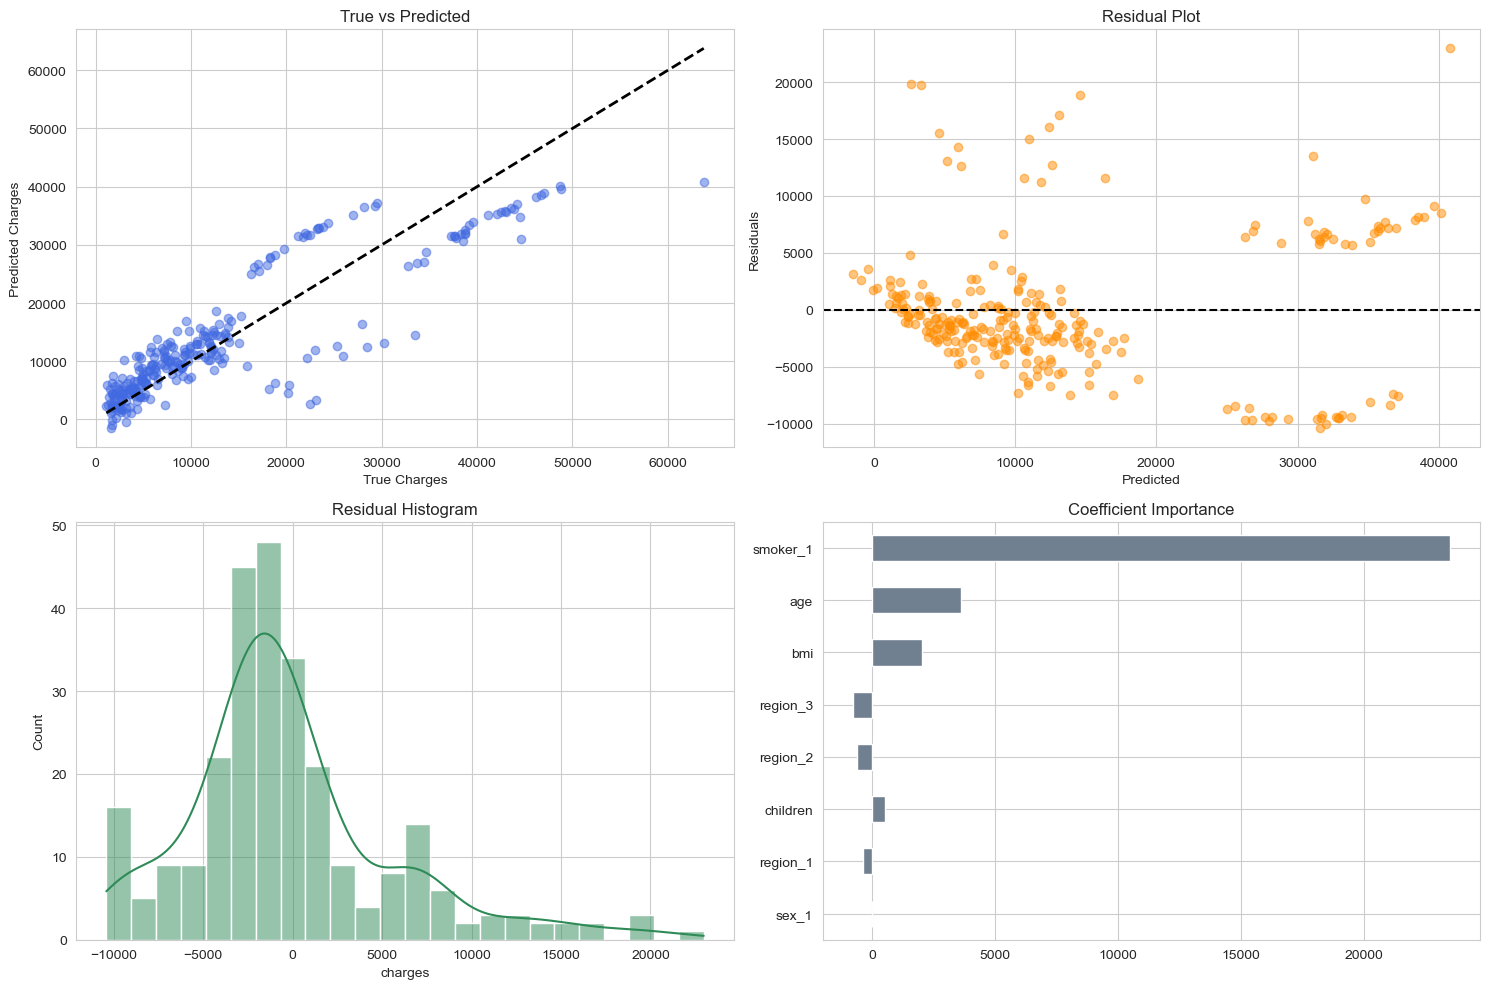

Best Params: {'en__alpha': 0.01, 'en__l1_ratio': 0.9}
Test R2 Score: 0.7833
Test RMSE: 5800.78


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Setup and Preprocessing
# Assume 'df' exists and 'charges' is the target
X = df.drop('charges', axis=1)
y = df['charges']

# Categorical vs Numerical identification
cat_cols = ['sex', 'smoker', 'region']
num_cols = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# 2. Modeling Setup
# Standard ElasticNet
en_pipe = Pipeline([('prep', preprocessor), ('en', ElasticNet())])

# ElasticNetCV (Automated hyperparameter path)
en_cv = Pipeline([('prep', preprocessor), 
                  ('en_cv', ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1], cv=5))])

# GridSearchCV (Exhaustive search)
param_grid = {'en__l1_ratio': [0.1, 0.5, 0.9], 'en__alpha': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(en_pipe, param_grid, cv=5, scoring='neg_mean_squared_error')

# 3. Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

# 4. Evaluation and Visualization
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# Plotting: Publication Quality Layout
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2)

# A. Predicted vs True
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
ax1.set(xlabel='True Charges', ylabel='Predicted Charges', title='True vs Predicted')

# B. Residual Plot
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred, residuals, alpha=0.5, color='darkorange')
ax2.axhline(0, color='black', linestyle='--')
ax2.set(xlabel='Predicted', ylabel='Residuals', title='Residual Plot')

# C. Residual Histogram
ax3 = fig.add_subplot(gs[1, 0])
sns.histplot(residuals, kde=True, ax=ax3, color='seagreen')
ax3.set(title='Residual Histogram')

# D. Coefficient Ranking
# Accessing preprocessor and estimator from pipeline
ohe = best_model.named_steps['prep'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(cat_cols)
all_names = np.concatenate([num_cols, cat_names])
coefs = pd.Series(best_model.named_steps['en'].coef_, index=all_names).sort_values(key=abs)

ax4 = fig.add_subplot(gs[1, 1])
coefs.plot(kind='barh', ax=ax4, color='slategray')
ax4.set(title='Coefficient Importance')

plt.tight_layout()
plt.savefig("../figures/elasticnet_report.pdf")
plt.show()

# 5. Performance Summary
print(f"Best Params: {grid.best_params_}")
print(f"Test R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Stacking Regressor Performance
MAE  : 2416.36
MSE  : 18656524.02
RMSE : 4319.32
R²   : 0.8798


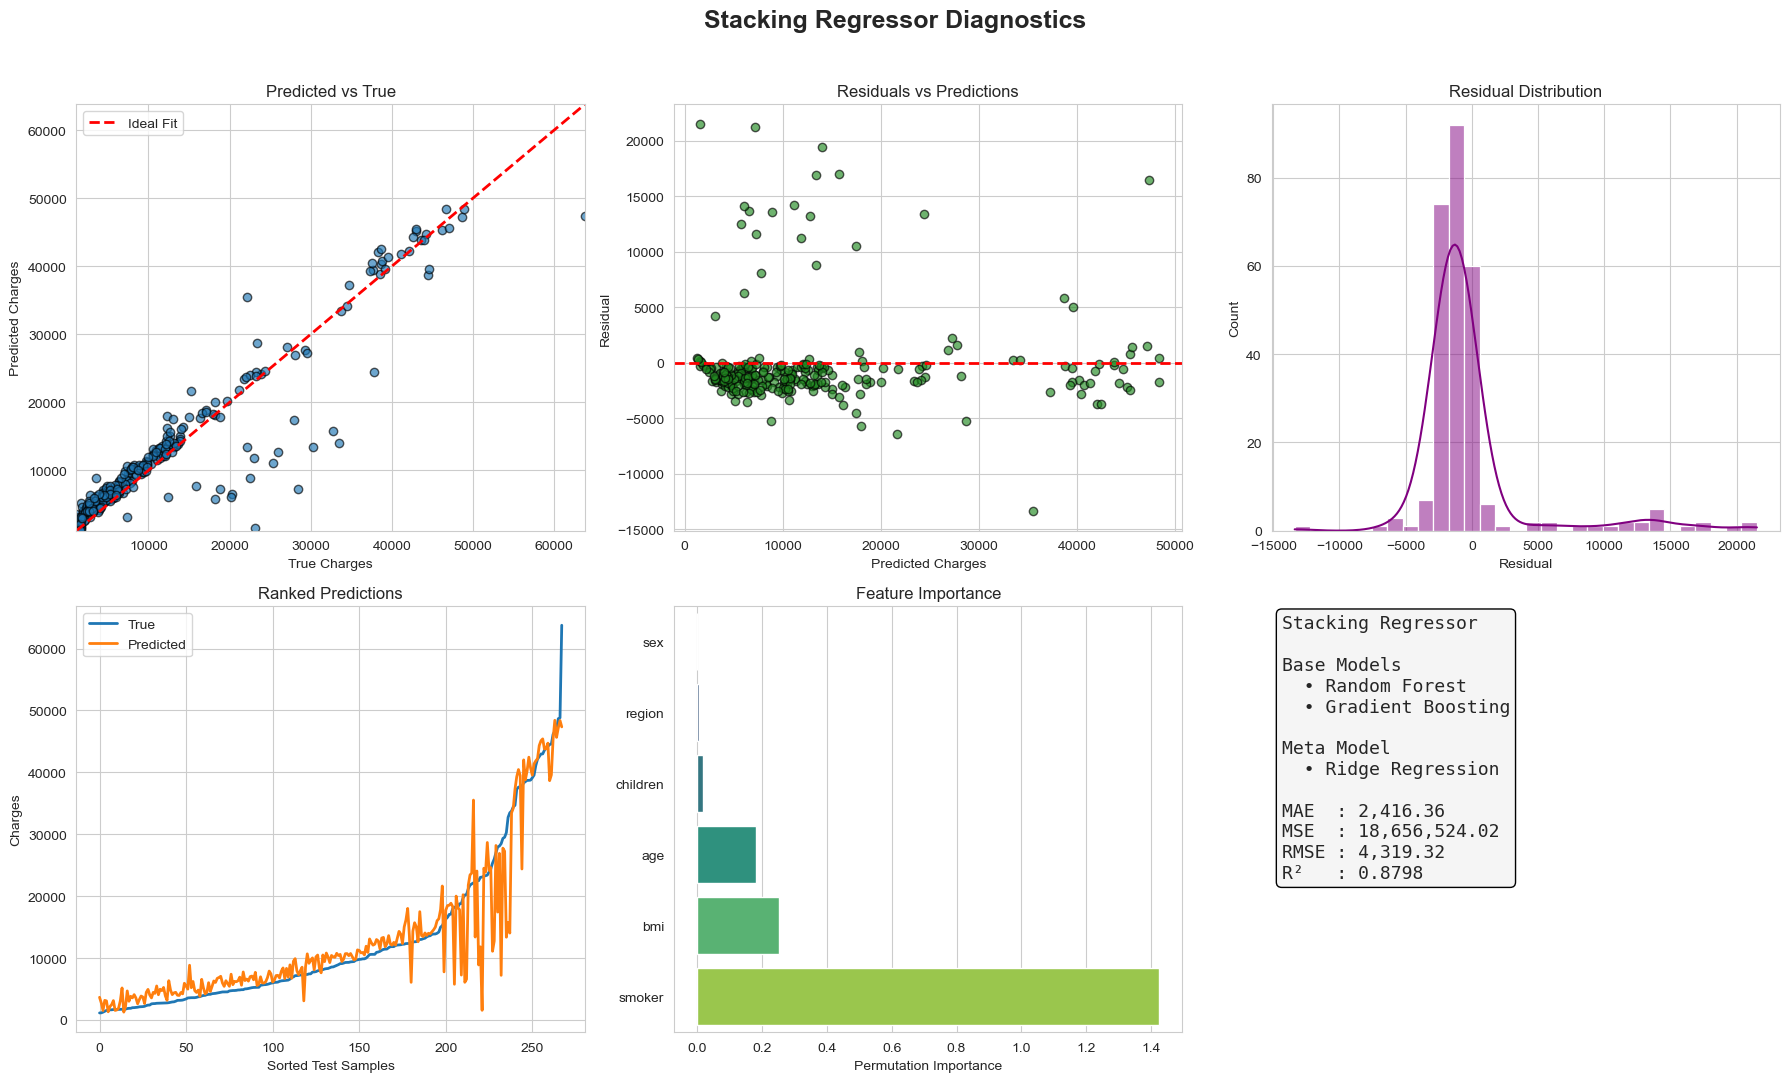

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================================
# Predictions
# ==========================================================

y_pred_stack = stack_pipe.predict(X_test)

residuals = y_test - y_pred_stack

# ==========================================================
# Performance Metrics
# ==========================================================

mae = mean_absolute_error(y_test, y_pred_stack)
mse = mean_squared_error(y_test, y_pred_stack)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_stack)

print("="*60)
print("Stacking Regressor Performance")
print("="*60)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# ==========================================================
# Permutation Feature Importance
# ==========================================================

perm = permutation_importance(
    stack_pipe,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="r2"
)

importance = (
    pd.Series(
        perm.importances_mean,
        index=X_test.columns
    )
    .sort_values()
)

# ==========================================================
# Plotting
# ==========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,11)
)

# ==========================================================
# 1. Predicted vs True
# ==========================================================

ax = axes[0,0]

ax.scatter(
    y_test,
    y_pred_stack,
    alpha=0.65,
    edgecolor='black'
)

limits = [
    min(y_test.min(), y_pred_stack.min()),
    max(y_test.max(), y_pred_stack.max())
]

ax.plot(
    limits,
    limits,
    'r--',
    linewidth=2,
    label='Ideal Fit'
)

ax.set_xlim(limits)
ax.set_ylim(limits)

ax.set_xlabel("True Charges")
ax.set_ylabel("Predicted Charges")
ax.set_title("Predicted vs True")
ax.legend()

# ==========================================================
# 2. Residual Plot
# ==========================================================

ax = axes[0,1]

ax.scatter(
    y_pred_stack,
    residuals,
    alpha=0.65,
    edgecolor='black',
    color='forestgreen'
)

ax.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2
)

ax.set_xlabel("Predicted Charges")
ax.set_ylabel("Residual")
ax.set_title("Residuals vs Predictions")

# ==========================================================
# 3. Residual Distribution
# ==========================================================

ax = axes[0,2]

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color='purple',
    ax=ax
)

ax.set_xlabel("Residual")
ax.set_title("Residual Distribution")

# ==========================================================
# 4. Ranked Prediction Plot
# ==========================================================

ax = axes[1,0]

order = np.argsort(y_test.values)

ax.plot(
    y_test.values[order],
    linewidth=2,
    label='True'
)

ax.plot(
    y_pred_stack[order],
    linewidth=2,
    label='Predicted'
)

ax.set_xlabel("Sorted Test Samples")
ax.set_ylabel("Charges")
ax.set_title("Ranked Predictions")
ax.legend()

# ==========================================================
# 5. Feature Importance
# ==========================================================

ax = axes[1,1]

sns.barplot(
    x=importance.values,
    y=importance.index,
    hue=importance.index,
    palette='viridis',
    legend=False,
    ax=ax
)

ax.set_xlabel("Permutation Importance")
ax.set_ylabel("")
ax.set_title("Feature Importance")

# ==========================================================
# 6. Performance Summary
# ==========================================================

ax = axes[1,2]

ax.axis("off")

summary = (
    f"Stacking Regressor\n\n"
    f"Base Models\n"
    f"  • Random Forest\n"
    f"  • Gradient Boosting\n\n"
    f"Meta Model\n"
    f"  • Ridge Regression\n\n"
    f"MAE  : {mae:,.2f}\n"
    f"MSE  : {mse:,.2f}\n"
    f"RMSE : {rmse:,.2f}\n"
    f"R²   : {r2:.4f}"
)

ax.text(
    0.02,
    0.98,
    summary,
    fontsize=13,
    va="top",
    family="monospace",
    bbox=dict(
        boxstyle="round",
        facecolor="whitesmoke",
        edgecolor="black"
    )
)

plt.suptitle(
    "Stacking Regressor Diagnostics",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.savefig(
    "../figures/stacking_regressor_diagnostics.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Stacked Regression is the best performer among the all algorithms.